In [17]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("../../tmp_data/merged_part_1.csv")
pd.set_option('display.max_columns', None)

In [18]:
df = df.drop(columns = [
        "ceiling_height",
        "metro_minutes",
        "metro_walking",
        "total_area",
        "living_area",
        "kitchen_area",
        "price",
        "utilities_amount",
        "utilities_included",
        "prepayment_months",
        "is_long_rental_term",
    ]
)

In [19]:
# ## Комнаты

# df["types_room"] = df["types_room"].str.replace(",", "").str.strip()
# df["types_room"] = df["types_room"].replace('', pd.NA)

# df["rooms_count_num"] = pd.to_numeric(df["rooms_count"], errors='coerce')

# df["rooms_count_num"] = df["rooms_count_num"].fillna(
#     df.apply(lambda x: max(1, round(
#         (x['total_area'] / 22 + 
#          (x['living_area'] / 15 if pd.notna(x['living_area']) else x['total_area'] / 25) +
#          (x['kitchen_area'] / 8 if pd.notna(x['kitchen_area']) else x['total_area'] / 30)
#         ) / 3 - 0.5
#     )) if pd.notna(x['total_area']) else np.nan, axis=1)
# )

# def check_isolated_room(types_room, rooms_count):
#     rooms_count_num = float(rooms_count) if rooms_count not in [None, 'nan', ''] else np.nan
    
#     if pd.isna(types_room):
#         return 0 if (rooms_count_num == 1) else None
#     if rooms_count_num == 2 and pd.notna(types_room) and 'Оба варианта' in str(types_room):
#         return 0
#     if pd.notna(types_room) and ('Изолированная' in str(types_room) or 'Оба варианта' in str(types_room)):
#         return 1
#     return 0

# def check_adjacent_room(types_room, rooms_count):
#     rooms_count_num = float(rooms_count) if rooms_count not in [None, 'nan', ''] else np.nan
    
#     if pd.isna(types_room):
#         return 0 if rooms_count_num == 1 else None
#     if rooms_count_num == 1:
#         return 0
#     if rooms_count_num == 2 and pd.notna(types_room) and 'Оба варианта' in str(types_room):
#         return 1
#     if pd.notna(types_room) and ('Смежная' in str(types_room) or 'Оба варианта' in str(types_room)):
#         return 1
#     return 0


# df["rooms_count_str"] = df["rooms_count_num"].astype(str)

# df['rooms_count'] = df['rooms_count_num']

# df['is_isolated'] = df.apply(lambda row: check_isolated_room(row['types_room'], row['rooms_count_str']), axis=1)
# df['is_adjacent'] = df.apply(lambda row: check_adjacent_room(row['types_room'], row['rooms_count_str']), axis=1)

# df = df.drop(columns=['rooms_count_num', 'rooms_count_str'])

In [20]:
## Дом

#df["house_tipe"].fillna

In [21]:
## Парковка

# df["parking"].fillna

In [22]:
## Ремонт

# df["renovation"].fillna

In [ ]:
## Балкон

# df['is_loggia'].fillna
# df['is_balcony'].fillna

In [24]:
## Окна

# df['view_of_courtyard'].fillna
# df['view_of_street'].fillna

In [25]:
## Санузел

df['combined_bathroom_count'] = np.where(df['combined_bathroom_count'].isna() & df['renovation'].isin([2, 3]), 1, np.where(df['combined_bathroom_count'].isna() & ~df['renovation'].isin([2, 3]), 0, df['combined_bathroom_count']))
df['separate_bathroom_count'] = np.where(df['separate_bathroom_count'].isna() & df['renovation'].isin([0, 1]), 1, np.where(df['separate_bathroom_count'].isna() & ~df['renovation'].isin([0, 1]), 0, df['separate_bathroom_count']))

In [26]:
## Можно с детьми/животными

df['is_child'] = df['is_child'].fillna(0).astype(int)
df['is_pet'] = df['is_pet'].fillna(0).astype(int)

In [27]:
## Дополнительно

df['room_furniture'] = df['room_furniture'].fillna(1).astype(int)
df['kitchen_furniture'] = df['kitchen_furniture'].fillna(1).astype(int)
df['bath'] = df['bath'].fillna(1).astype(int)
df['shower_cabin'] = np.where(df['shower_cabin'].isna() & df['renovation'].isin([3]), 1, np.where(df['shower_cabin'].isna() & ~df['renovation'].isin([3]), 0, df['shower_cabin']))
df['washing_machine'] = df['washing_machine'].fillna(1).astype(int)
df['air_conditioner'] = np.where(df['air_conditioner'].isna() & df['renovation'].isin([3]), 1, np.where(df['air_conditioner'].isna() & ~df['renovation'].isin([3]), 0, df['air_conditioner']))
df['dishwasher'] = np.where(df['dishwasher'].isna() & df['renovation'].isin([3]), 1, np.where(df['dishwasher'].isna() & ~df['renovation'].isin([3]), 0, df['dishwasher']))
df['tv'] = np.where(df['tv'].isna() & df['renovation'].isin([1, 2, 3]), 1, np.where(df['tv'].isna() & ~df['renovation'].isin([1, 2, 3]), 0, df['tv']))
df['fridge'] = df['fridge'].fillna(1).astype(int)
df['internet'] = df['internet'].fillna(1).astype(int)
df['telephone'] = df['telephone'].fillna(0).astype(int)

In [28]:
## Лифт 

df['count_passenger_lift'] = df['count_passenger_lift'].apply(lambda x: np.nan if not pd.isna(x) and x > 10 else x)
df['count_freight_lift'] = df['count_freight_lift'].apply(lambda x: np.nan if not pd.isna(x) and x > 10 else x)

df['count_passenger_lift'] = df['count_passenger_lift'].fillna(df.apply(lambda x: 0 if x['house_floor'] <= 5 else 1, axis=1))
df['count_freight_lift'] = df['count_freight_lift'].fillna(df.apply(lambda x: 1 if x['house_floor'] > 16 or (10 <= x['house_floor'] <= 16 and x['house_type'] in [5, 8, 9]) else 0, axis=1))

In [29]:
## Мусоропровод

def fill_garbage_chute(row):
    house_type = row['house_type']
    house_floor = row['house_floor']
    has_lift = row['count_passenger_lift'] > 0 or row['count_freight_lift'] > 0
    
    if pd.isna(house_type):
        return np.nan
    
    house_type = int(house_type)  # конвертируем float в int

    if house_type in [0, 1]:  # Панельный, Блочный
        return 1 if house_floor >= 9 else 0
    
    elif house_type in [2, 3]:  # Щитовой, Деревянный
        return 0

    elif house_type == 4:  # Газобетонный
        return 1 if (house_floor >= 12 and has_lift) else 0
    
    elif house_type == 5:  # Кирпичный
        return 1 if house_floor >= 5 else 0
    
    elif house_type == 6:  # Сталинский
        return 1 if house_floor > 10 else 0
    
    elif house_type == 7:  # Старый фонд
        return 0
    
    elif house_type == 8:  # Монолитно-кирпичный
        return 1 if (house_floor >= 17 and has_lift) else 0
    
    # Монолитные
    elif house_type == 9:  # Монолитный
        return 0
    
    else:
        return np.nan

# Применяем функцию
df['is_garbage_chute'] = df.apply(fill_garbage_chute, axis=1)

In [ ]:
df.to_csv('../../tmp_data/vanya_processed_part_2.csv', index=False)

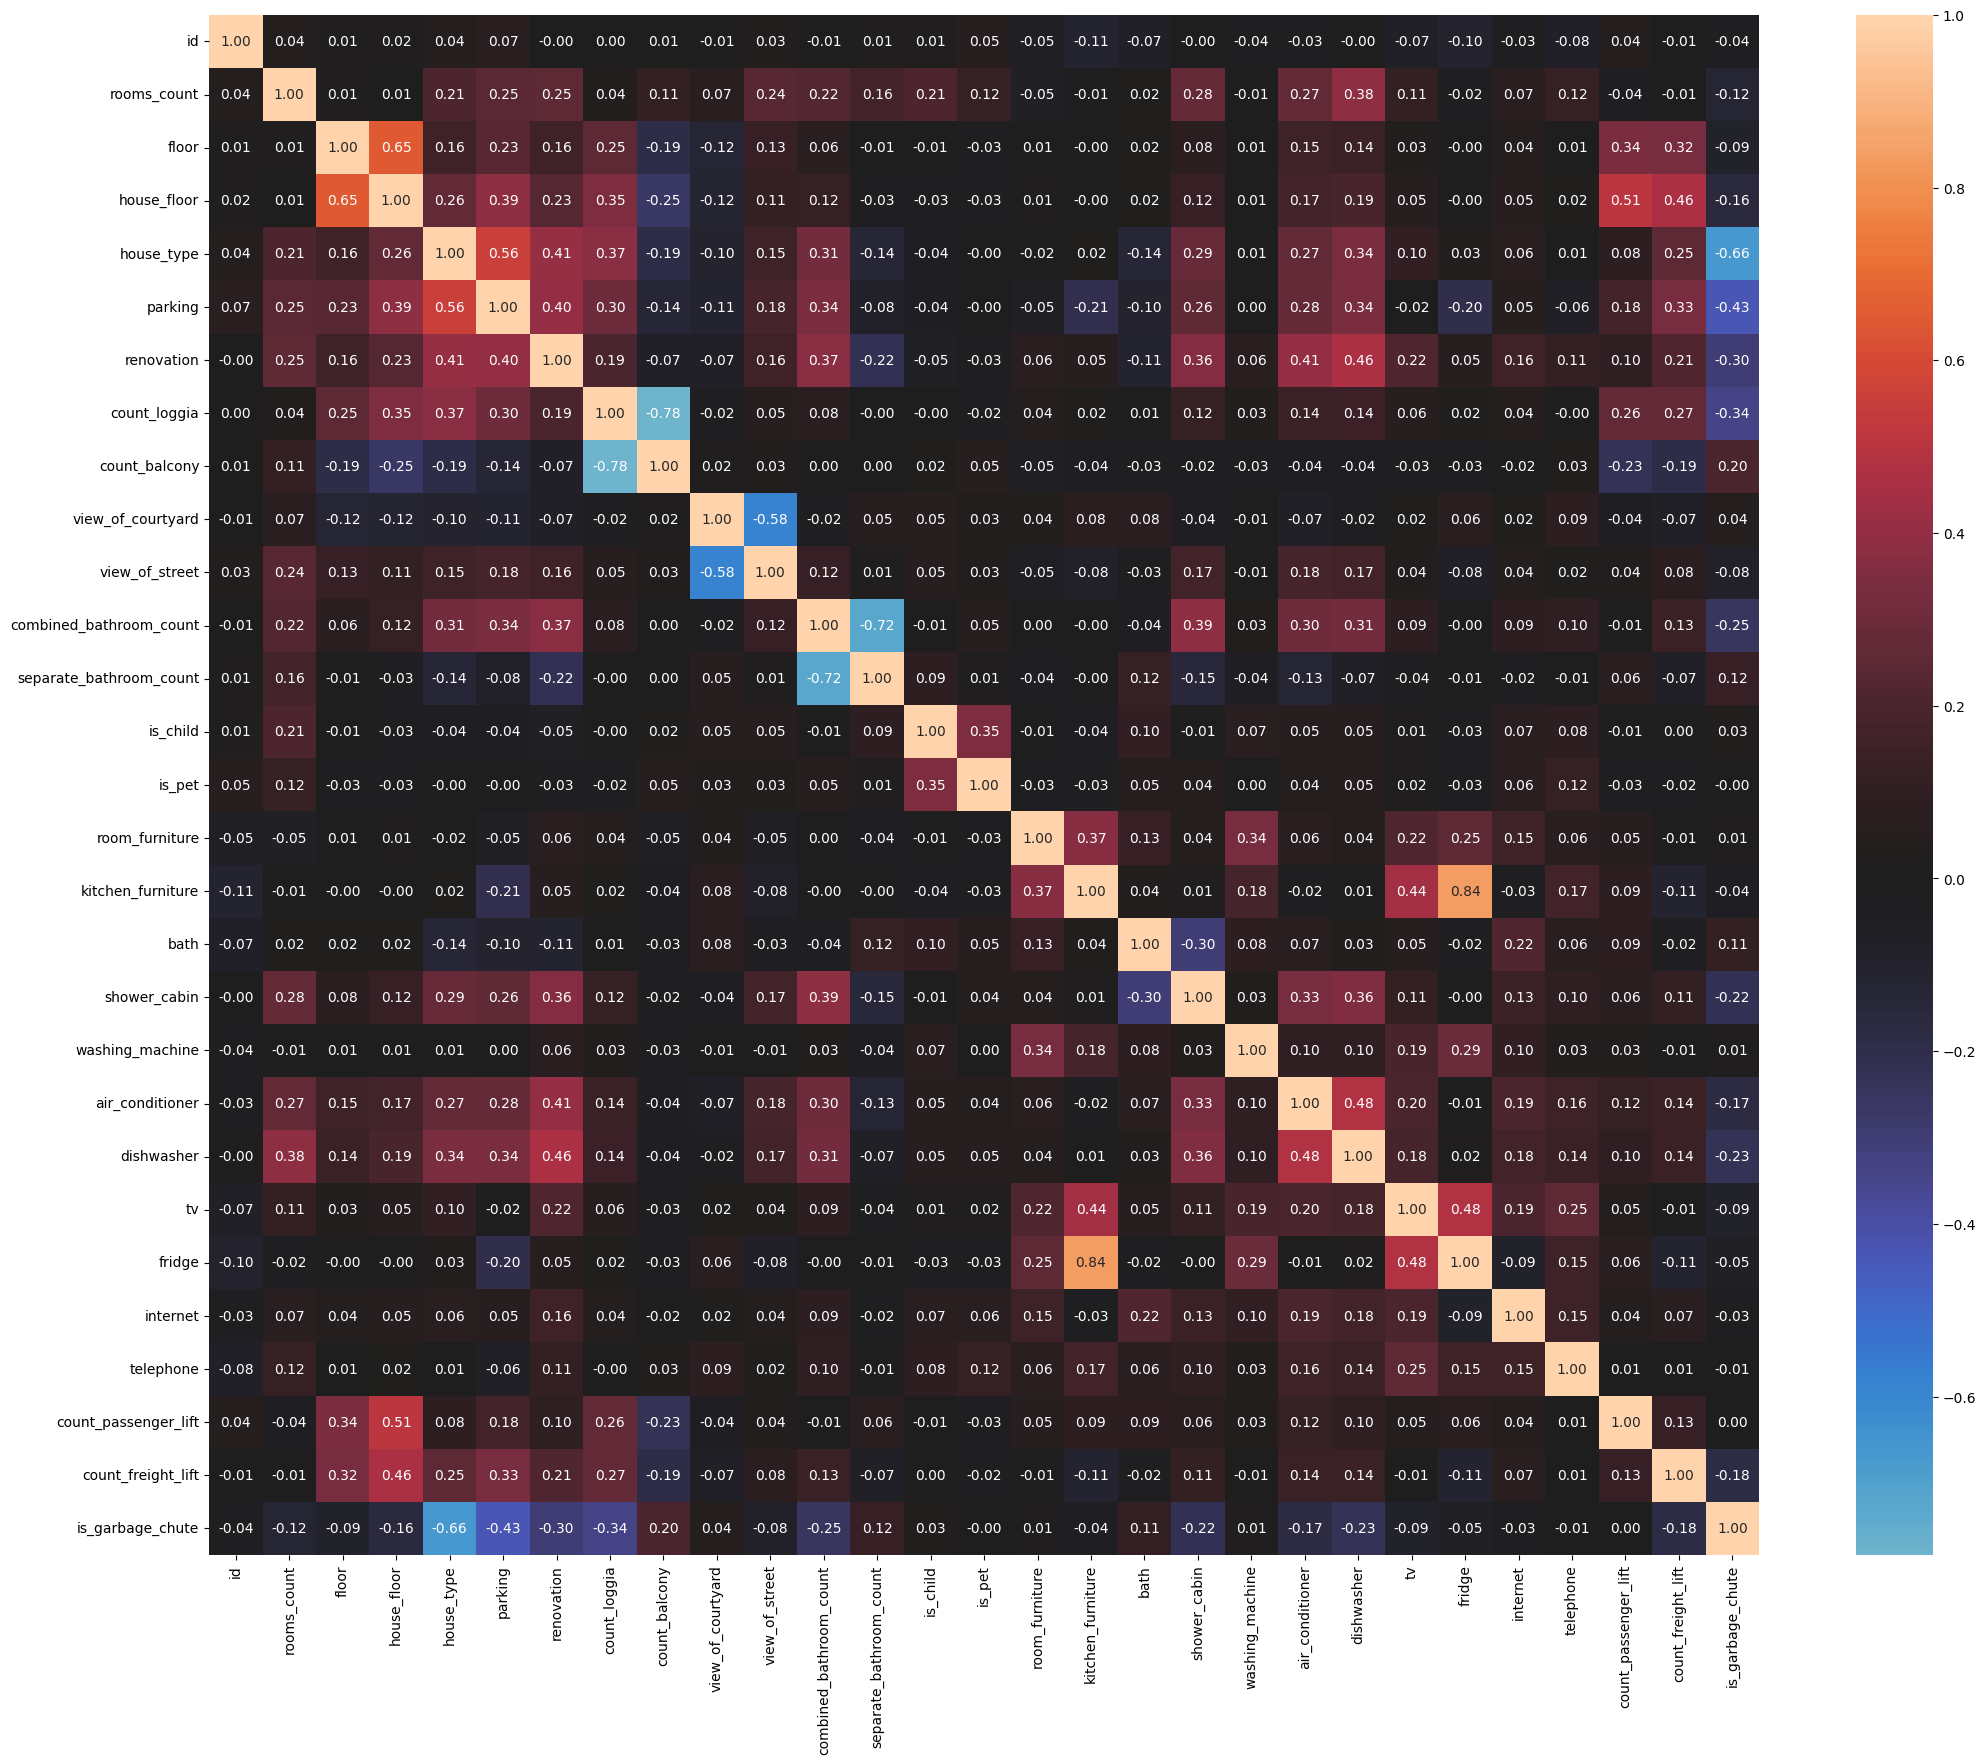

In [ ]:
plt.figure(figsize=(25, 20))
sns.heatmap(df.corr(numeric_only = True), annot = True, center = 0, fmt = ".2f");